In [20]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/raw/transaction_dataset.csv")

df = df.drop(columns=["Index", "Address", "Unnamed: 0"], errors="ignore")
df = df.dropna()

X = df.drop("FLAG", axis=1)
X = X.select_dtypes(include=[np.number])

In [1]:
import pandas as pd

df = pd.read_csv("data/raw/transaction_dataset.csv")

df.head()

,Unnamed: 0,Index,Address,FLAG,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,...,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 min val sent contract,ERC20 max val sent contract,ERC20 avg val sent contract,ERC20 uniq sent token name,ERC20 uniq rec token name,ERC20 most sent token type,ERC20_most_rec_token_type
0,0,1,0x00009277775ac7d0d59eaad8fee3d10ac6c805e8,0,844.26,1093.71,704785.63,721,89,0,...,0.000000,1.683100e+07,271779.920000,0.0,0.0,0.0,39.0,57.0,Cofoundit,Numeraire
1,1,2,0x0002b44ddb1476db43c868bd494422ee4c136fed,0,12709.07,2958.44,1218216.73,94,8,0,...,2.260809,2.260809e+00,2.260809,0.0,0.0,0.0,1.0,7.0,Livepeer Token,Livepeer Token
2,2,3,0x0002bda54cb772d040f779e88eb453cac0daa244,0,246194.54,2434.02,516729.30,2,10,0,...,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,8.0,NaN,XENON
3,3,4,0x00038e6ba2fd5c09aedb96697c8d7b8fa6632e5e,0,10219.60,15785.09,397555.90,25,9,0,...,100.000000,9.029231e+03,3804.076893,0.0,0.0,0.0,1.0,11.0,Raiden,XENON
4,4,5,0x00062d1dd1afb6fb02540ddad9cdebfe568e0d89,0,36.61,10707.77,382472.42,4598,20,1,...,0.000000,4.500000e+04,13726.659220,0.0,0.0,0.0,6.0,27.0,StatusNetwork,EOS


In [3]:
df.info()
df["FLAG"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9841 entries, 0 to 9840
Data columns (total 51 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   Unnamed: 0                                            9841 non-null   int64  
 1   Index                                                 9841 non-null   int64  
 2   Address                                               9841 non-null   object 
 3   FLAG                                                  9841 non-null   int64  
 4   Avg min between sent tnx                              9841 non-null   float64
 5   Avg min between received tnx                          9841 non-null   float64
 6   Time Diff between first and last (Mins)               9841 non-null   float64
 7   Sent tnx                                              9841 non-null   int64  
 8   Received Tnx                                          9841

FLAG
0    7662
1    2179
Name: count, dtype: int64

In [5]:
df.shape

(9841, 51)

In [8]:
df["FLAG"].value_counts()

FLAG
0    7662
1    2179
Name: count, dtype: int64

In [10]:
df["FLAG"].value_counts(normalize=True)

FLAG
0    0.778579
1    0.221421
Name: proportion, dtype: float64

In [12]:
df = df.drop(columns=["Index", "Address"], errors="ignore")

In [14]:
df.isnull().sum()

Unnamed: 0                                                 0
FLAG                                                       0
Avg min between sent tnx                                   0
Avg min between received tnx                               0
Time Diff between first and last (Mins)                    0
Sent tnx                                                   0
Received Tnx                                               0
Number of Created Contracts                                0
Unique Received From Addresses                             0
Unique Sent To Addresses                                   0
min value received                                         0
max value received                                         0
avg val received                                           0
min val sent                                               0
max val sent                                               0
avg val sent                                               0
min value sent to contra

In [16]:
df = df.dropna()

In [18]:
df.isnull().sum()

Unnamed: 0                                              0
FLAG                                                    0
Avg min between sent tnx                                0
Avg min between received tnx                            0
Time Diff between first and last (Mins)                 0
Sent tnx                                                0
Received Tnx                                            0
Number of Created Contracts                             0
Unique Received From Addresses                          0
Unique Sent To Addresses                                0
min value received                                      0
max value received                                      0
avg val received                                        0
min val sent                                            0
max val sent                                            0
avg val sent                                            0
min value sent to contract                              0
max val sent t

In [20]:
from sklearn.model_selection import train_test_split

X = df.drop("FLAG", axis=1)
y = df["FLAG"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

ValueError: could not convert string to float: ' '

In [24]:
df.dtypes

Unnamed: 0                                                int64
FLAG                                                      int64
Avg min between sent tnx                                float64
Avg min between received tnx                            float64
Time Diff between first and last (Mins)                 float64
Sent tnx                                                  int64
Received Tnx                                              int64
Number of Created Contracts                               int64
Unique Received From Addresses                            int64
Unique Sent To Addresses                                  int64
min value received                                      float64
max value received                                      float64
avg val received                                        float64
min val sent                                            float64
max val sent                                            float64
avg val sent                            

In [26]:
import numpy as np

X = df.drop("FLAG", axis=1)

X = X.select_dtypes(include=[np.number])
y = df["FLAG"]

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [32]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [34]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1172
           1       1.00      1.00      1.00       253

    accuracy                           1.00      1425
   macro avg       1.00      1.00      1.00      1425
weighted avg       1.00      1.00      1.00      1425



In [36]:
df.duplicated().sum()

0

In [38]:
X.duplicated().sum()

0

In [40]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(15)

Unnamed: 0                                 0.277647
 Total ERC20 tnxs                          0.127552
 ERC20 uniq rec token name                 0.108097
 ERC20 uniq rec addr                       0.099193
 ERC20 uniq rec contract addr              0.069172
 ERC20 min val rec                         0.040542
Time Diff between first and last (Mins)    0.025791
 ERC20 uniq sent token name                0.025404
avg val received                           0.024518
 ERC20 uniq sent addr                      0.022625
Sent tnx                                   0.016151
 ERC20 max val sent                        0.014748
total ether received                       0.014213
max value received                         0.013699
total Ether sent                           0.013377
dtype: float64

In [42]:
df.corr(numeric_only=True)["FLAG"].sort_values(ascending=False).head(15)

FLAG                                1.000000
Unnamed: 0                          0.691386
min val sent                        0.041735
 ERC20 min val sent                 0.024707
 ERC20 avg val sent                 0.024431
 ERC20 max val sent                 0.024385
 ERC20 total ether sent             0.024024
Avg min between sent tnx            0.019526
 ERC20 total Ether sent contract    0.019112
 ERC20 min val rec                  0.009114
 ERC20 avg val rec                  0.007595
total ether balance                 0.005553
 ERC20 uniq sent addr.1             0.003487
 ERC20 max val rec                 -0.005622
 ERC20 total Ether received        -0.005817
Name: FLAG, dtype: float64

In [44]:
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

In [46]:
import numpy as np

X = df.drop("FLAG", axis=1)
X = X.select_dtypes(include=[np.number])
y = df["FLAG"]

In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [52]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [54]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1172
           1       1.00      0.94      0.97       253

    accuracy                           0.99      1425
   macro avg       0.99      0.97      0.98      1425
weighted avg       0.99      0.99      0.99      1425



In [56]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)

array([[1172,    0],
       [  16,  237]])

In [58]:
y_proba = model.predict_proba(X_test)[:, 1]

# lower threshold
y_pred_new = (y_proba > 0.3).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_new))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1172
           1       0.99      0.97      0.98       253

    accuracy                           0.99      1425
   macro avg       0.99      0.99      0.99      1425
weighted avg       0.99      0.99      0.99      1425



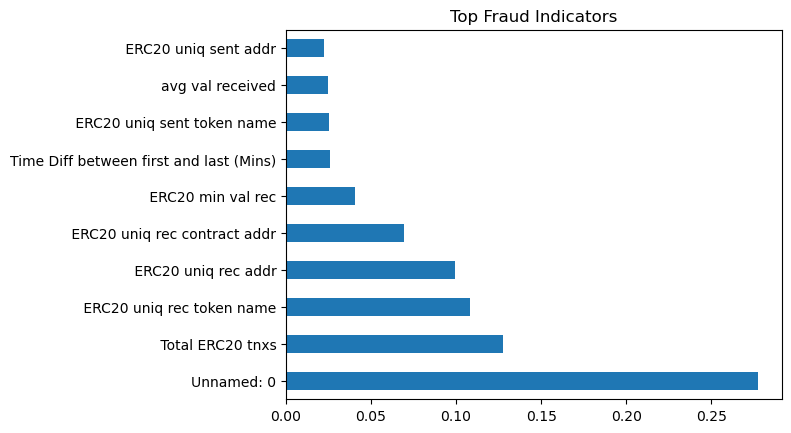

In [60]:
import matplotlib.pyplot as plt

importance.sort_values(ascending=False).head(10).plot(kind='barh')
plt.title("Top Fraud Indicators")
plt.show()

In [2]:
sample = X.iloc[0].to_dict()
sample

NameError: name 'X' is not defined

In [4]:
sample = X.iloc[0].to_dict()


NameError: name 'X' is not defined

In [8]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/raw/transaction_dataset.csv")

df = df.drop(columns=["Index", "Address", "Unnamed: 0"], errors="ignore")
df = df.dropna()

X = df.drop("FLAG", axis=1)
X = X.select_dtypes(include=[np.number])

In [10]:
sample = X.iloc[0].to_dict()
sample

{'Avg min between sent tnx': 844.26,
 'Avg min between received tnx': 1093.71,
 'Time Diff between first and last (Mins)': 704785.63,
 'Sent tnx': 721.0,
 'Received Tnx': 89.0,
 'Number of Created Contracts': 0.0,
 'Unique Received From Addresses': 40.0,
 'Unique Sent To Addresses': 118.0,
 'min value received': 0.0,
 'max value received ': 45.806785,
 'avg val received': 6.589513,
 'min val sent': 0.0,
 'max val sent': 31.22,
 'avg val sent': 1.200681,
 'min value sent to contract': 0.0,
 'max val sent to contract': 0.0,
 'avg value sent to contract': 0.0,
 'total transactions (including tnx to create contract': 810.0,
 'total Ether sent': 865.6910932,
 'total ether received': 586.4666748,
 'total ether sent contracts': 0.0,
 'total ether balance': -279.2244185,
 ' Total ERC20 tnxs': 265.0,
 ' ERC20 total Ether received': 35588543.78,
 ' ERC20 total ether sent': 35603169.52,
 ' ERC20 total Ether sent contract': 0.0,
 ' ERC20 uniq sent addr': 30.0,
 ' ERC20 uniq rec addr': 54.0,
 ' ERC

In [12]:
payload = {
    "features": sample
}

payload

{'features': {'Avg min between sent tnx': 844.26,
  'Avg min between received tnx': 1093.71,
  'Time Diff between first and last (Mins)': 704785.63,
  'Sent tnx': 721.0,
  'Received Tnx': 89.0,
  'Number of Created Contracts': 0.0,
  'Unique Received From Addresses': 40.0,
  'Unique Sent To Addresses': 118.0,
  'min value received': 0.0,
  'max value received ': 45.806785,
  'avg val received': 6.589513,
  'min val sent': 0.0,
  'max val sent': 31.22,
  'avg val sent': 1.200681,
  'min value sent to contract': 0.0,
  'max val sent to contract': 0.0,
  'avg value sent to contract': 0.0,
  'total transactions (including tnx to create contract': 810.0,
  'total Ether sent': 865.6910932,
  'total ether received': 586.4666748,
  'total ether sent contracts': 0.0,
  'total ether balance': -279.2244185,
  ' Total ERC20 tnxs': 265.0,
  ' ERC20 total Ether received': 35588543.78,
  ' ERC20 total ether sent': 35603169.52,
  ' ERC20 total Ether sent contract': 0.0,
  ' ERC20 uniq sent addr': 30.0

In [16]:
import json

sample = X.iloc[0].to_dict()
payload = {"features": sample}

print(json.dumps(payload, indent=2))

{
  "features": {
    "Avg min between sent tnx": 844.26,
    "Avg min between received tnx": 1093.71,
    "Time Diff between first and last (Mins)": 704785.63,
    "Sent tnx": 721.0,
    "Received Tnx": 89.0,
    "Number of Created Contracts": 0.0,
    "Unique Received From Addresses": 40.0,
    "Unique Sent To Addresses": 118.0,
    "min value received": 0.0,
    "max value received ": 45.806785,
    "avg val received": 6.589513,
    "min val sent": 0.0,
    "max val sent": 31.22,
    "avg val sent": 1.200681,
    "min value sent to contract": 0.0,
    "max val sent to contract": 0.0,
    "avg value sent to contract": 0.0,
    "total transactions (including tnx to create contract": 810.0,
    "total Ether sent": 865.6910932,
    "total ether received": 586.4666748,
    "total ether sent contracts": 0.0,
    "total ether balance": -279.2244185,
    " Total ERC20 tnxs": 265.0,
    " ERC20 total Ether received": 35588543.78,
    " ERC20 total ether sent": 35603169.52,
    " ERC20 total 

In [22]:
df_clean.to_csv("data/processed/cleaned_dataset.csv", index=False)


NameError: name 'df_clean' is not defined